# An Introduction to CLIP — Understanding Vision–Language Models

**A hands-on, from-the-ground-up tutorial.**

CLIP (*Contrastive Language–Image Pre-training*, Radford et al., 2021) is the model that made
"zero-shot" image classification practical: you can ask it *"is this a photo of a cat or a dog?"*
without ever training it on cats or dogs. It does this by learning a **single shared embedding
space** for images and text, so that a picture of a dog lands near the words *"a photo of a dog."*

This notebook builds that intuition piece by piece:

1. The core idea — contrastive learning and the shared embedding space
2. Loading a CLIP model and inspecting its two towers
3. Encoding images and text into vectors
4. Cosine similarity: how "closeness" is measured
5. Zero-shot classification, step by step
6. Prompt engineering — why *how* you phrase a label matters
7. Image ↔ text retrieval
8. Visualizing the embedding space
9. Limitations and failure modes
10. Where this leads next (multilingual CLIP & robustness)

> **Runtime.** A GPU is helpful but not required for the small examples here. In Google Colab
> choose *Runtime → Change runtime type → GPU*. Everything also runs on CPU, just slower.


## 1. The core idea: contrastive learning

A traditional image classifier has a fixed list of output classes baked into its final layer.
Want a new class? Retrain. CLIP throws that design out.

Instead, CLIP has **two encoders**:

- an **image encoder** $f_{\text{img}}$ (a ViT or ResNet) that turns an image into a vector, and
- a **text encoder** $f_{\text{txt}}$ (a Transformer) that turns a caption into a vector.

Both vectors live in the **same** $d$-dimensional space. During training on hundreds of millions
of (image, caption) pairs scraped from the web, CLIP is optimized with a **contrastive loss**:
for each batch of $N$ pairs, pull the matching image–caption vectors together and push the
$N^2 - N$ mismatched pairs apart.

Concretely, with L2-normalized image features $I_i$ and text features $T_j$, CLIP forms a
similarity matrix $S_{ij} = \tau \cdot I_i \cdot T_j$ (where $\tau$ is a learned temperature /
"logit scale") and applies a symmetric cross-entropy that says *"row $i$ should match column $i$."*

The payoff: once trained, **any** text string becomes a usable classifier weight. To classify an
image among $K$ classes you just encode $K$ text prompts and pick the nearest one. That is what
"zero-shot" means here — no task-specific training data.


### A picture of the training objective

```
            captions →   "a dog"  "a cat"  "a car"   ...
                        ┌────────┬────────┬────────┐
   images ↓            │        │        │        │
   🐕  "a dog"  →  I₁  │  ✓high │  low   │  low   │   ← row 1 should pick column 1
   🐈  "a cat"  →  I₂  │  low   │  ✓high │  low   │
   🚗  "a car"  →  I₃  │  low   │  low   │  ✓high │
                        └────────┴────────┴────────┘
                          T₁       T₂       T₃
        Sᵢⱼ = logit_scale · (Iᵢ · Tⱼ)     (Iᵢ, Tⱼ are L2-normalized)
```

The diagonal is maximized; everything off-diagonal is minimized. After training, the image and
text towers can be used **independently** — encode an image once, compare it against as many text
labels as you like.


## 2. Setup

We use [`open_clip`](https://github.com/mlfoundations/open_clip), an open reproduction of CLIP
that exposes many pretrained checkpoints through one API. We'll use the original OpenAI
`ViT-B-32` weights here because they're small and widely studied.


In [44]:
# Install dependencies (safe to re-run; skip the line if already installed)
%pip install -q open_clip_torch torch torchvision matplotlib pillow pandas


Note: you may need to restart the kernel to use updated packages.


In [45]:
import torch
import torch.nn.functional as F
import open_clip
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request, io

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("Using device:", device)
print("open_clip version:", open_clip.__version__)


Using device: cuda
open_clip version: 3.3.0


### The two-tower architecture at a glance

Before loading the model, here is Section 1's idea as a diagram. Two independent encoders map an
image and a caption into the **same** vector space; classification is just comparing directions
(cosine similarity) in that space.


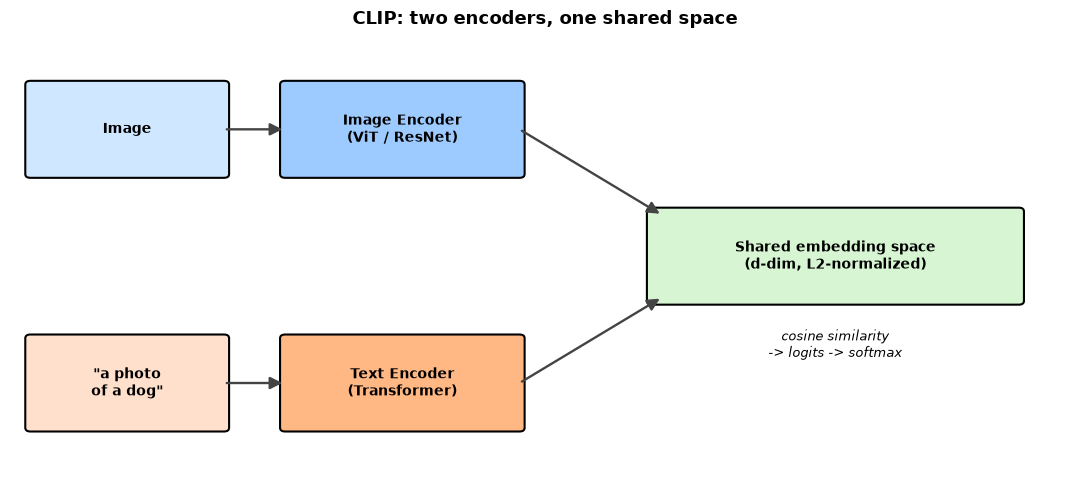

In [46]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 5)); ax.axis("off")
ax.set_xlim(0, 10.5); ax.set_ylim(0, 6)

def _box(x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                fc=color, ec="black", lw=1.5))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10, weight="bold")

def _arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=18, lw=1.7, color="#444"))

_box(0.2, 4.1, 1.9, 1.2, "Image", "#cfe8ff")
_box(2.7, 4.1, 2.3, 1.2, "Image Encoder\n(ViT / ResNet)", "#9ecbff")
_arrow(2.1, 4.7, 2.7, 4.7)

_box(0.2, 0.7, 1.9, 1.2, '"a photo\nof a dog"', "#ffe0cc")
_box(2.7, 0.7, 2.3, 1.2, "Text Encoder\n(Transformer)", "#ffb784")
_arrow(2.1, 1.3, 2.7, 1.3)

_box(6.3, 2.4, 3.6, 1.2, "Shared embedding space\n(d-dim, L2-normalized)", "#d7f5d3")
_arrow(5.0, 4.7, 6.4, 3.55)
_arrow(5.0, 1.3, 6.4, 2.45)
ax.text(8.1, 1.65, "cosine similarity\n-> logits -> softmax", ha="center", fontsize=9, style="italic")
ax.set_title("CLIP: two encoders, one shared space", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()


In [47]:
# Load a pretrained CLIP: the original OpenAI ViT-B/32.
# `create_model_and_transforms` returns the model + the matching image preprocessing.
model_name, pretrained = "ViT-B-32", "openai"
model, _, preprocess = open_clip.create_model_and_transforms(
    model_name, pretrained=pretrained
)
tokenizer = open_clip.get_tokenizer(model_name)
model = model.to(device).eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded {model_name} ({pretrained}) — {n_params/1e6:.1f}M parameters")
print("Embedding dimension:", model.text_projection.shape[1])
print("Learned logit scale (temperature):", model.logit_scale.exp().item())


d:\ian\2026summer\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded ViT-B-32 (openai) — 151.3M parameters
Embedding dimension: 512
Learned logit scale (temperature): 100.0


### Inspecting the two towers

`model.encode_image` and `model.encode_text` are the two functions we care about. Notice that the
image side is a vision Transformer and the text side is a separate Transformer — they only meet at
the shared output dimension.


In [48]:
print("Image encoder (truncated):")
print(str(model.visual)[:600], "...\n")
print("Image preprocessing pipeline:")
print(preprocess)


Image encoder (truncated):
VisionTransformer(
  (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
  (patch_dropout): Identity()
  (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (transformer): Transformer(
    (resblocks): ModuleList(
      (0-11): 12 x ResidualAttentionBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (ls_1): Identity()
        (ln_2): LayerNorm((768,), eps=1e- ...

Image preprocessing pipeline:
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


## 3. Encoding images and text

Let's fetch a few public-domain images and turn both the images and some candidate captions into
vectors. The key methods:

- `preprocess(PIL_image)` → a normalized `(3, 224, 224)` tensor ready for the image encoder.
- `tokenizer([...])` → integer token IDs for the text encoder.


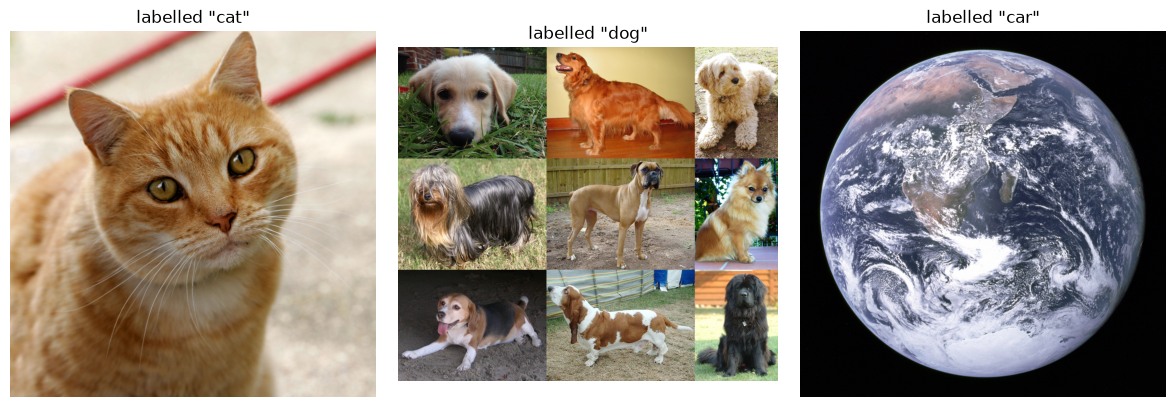

In [49]:
# A few Wikimedia Commons images (public domain / CC). If your environment blocks
# downloads, replace these URLs with local file paths via Image.open("path.jpg").
IMAGE_URLS = {
    "cat":  "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    "dog":  "https://upload.wikimedia.org/wikipedia/commons/d/d9/Collage_of_Nine_Dogs.jpg",
    "car":  "https://upload.wikimedia.org/wikipedia/commons/9/97/The_Earth_seen_from_Apollo_17.jpg",
}

def load_image(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    data = urllib.request.urlopen(req, timeout=30).read()
    return Image.open(io.BytesIO(data)).convert("RGB")

# NOTE: the "car" URL above is intentionally the famous Earth photo — a deliberate
# mislabel so you can see later how CLIP handles a label that doesn't fit.
images = {name: load_image(url) for name, url in IMAGE_URLS.items()}

fig, axes = plt.subplots(1, len(images), figsize=(12, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img); ax.set_title(f'labelled "{name}"'); ax.axis("off")
plt.tight_layout(); plt.show()


In [50]:
# Encode the images -> L2-normalized feature vectors
image_tensors = torch.stack([preprocess(img) for img in images.values()]).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_tensors)
    image_features = F.normalize(image_features, dim=-1)

print("image_features shape:", tuple(image_features.shape))  # (num_images, dim)
print("Each vector is unit length:", image_features.norm(dim=-1).round(decimals=3).tolist())


image_features shape: (3, 512)
Each vector is unit length: [1.0, 1.0, 1.0]


In [51]:
# Encode some candidate text labels
labels = ["a cat", "a dog", "a car", "the planet Earth", "a bird", "a sandwich"]
prompts = [f"a photo of {l}" for l in labels]

text_tokens = tokenizer(prompts).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = F.normalize(text_features, dim=-1)

print("text_features shape:", tuple(text_features.shape))  # (num_labels, dim)


text_features shape: (6, 512)


## 4. Cosine similarity: measuring closeness

Because every vector is L2-normalized, the dot product between an image vector and a text vector is
exactly their **cosine similarity** — a number in $[-1, 1]$ where higher means "more aligned."
CLIP multiplies this by the learned `logit_scale` (temperature) before the softmax, which sharpens
the distribution.

Let's compute the full image × text similarity matrix.


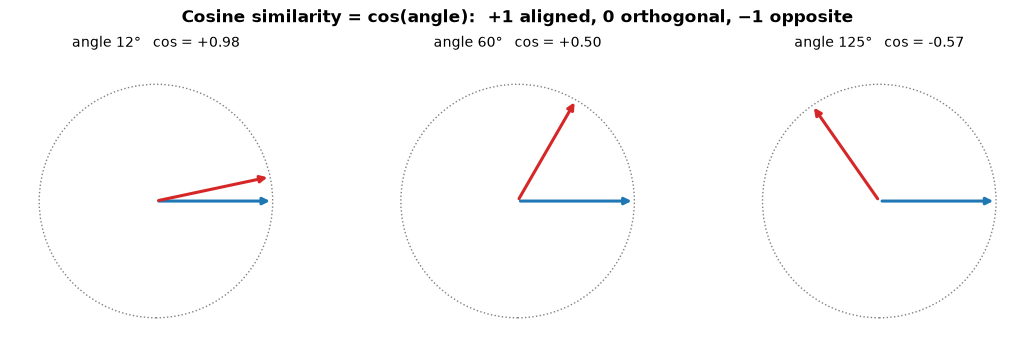

In [52]:
# Intuition first: cosine similarity is just the cosine of the angle between two unit vectors.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, ang in zip(axes, [12, 60, 125]):
    th = np.deg2rad(ang)
    ax.add_artist(plt.Circle((0, 0), 1, fill=False, ls=":", color="gray"))
    ax.annotate("", (1, 0), (0, 0), arrowprops=dict(arrowstyle="-|>", color="tab:blue", lw=2.2))
    ax.annotate("", (np.cos(th), np.sin(th)), (0, 0),
                arrowprops=dict(arrowstyle="-|>", color="tab:red", lw=2.2))
    ax.set_title(f"angle {ang}°   cos = {np.cos(th):+.2f}", fontsize=10)
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25); ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Cosine similarity = cos(angle):  +1 aligned, 0 orthogonal, −1 opposite",
             weight="bold")
plt.tight_layout(); plt.show()


In [53]:
with torch.no_grad():
    sims = image_features @ text_features.T          # cosine similarities, shape (imgs, labels)

import pandas as pd
df = pd.DataFrame(sims.cpu().numpy(),
                  index=[f'img:{n}' for n in images],
                  columns=labels).round(3)
print("Cosine similarity (image rows × label columns):\n")
print(df)


Cosine similarity (image rows × label columns):

         a cat  a dog  a car  the planet Earth  a bird  a sandwich
img:cat  0.270  0.224  0.199             0.180   0.208       0.197
img:dog  0.157  0.247  0.152             0.166   0.153       0.186
img:car  0.194  0.192  0.209             0.321   0.208       0.240


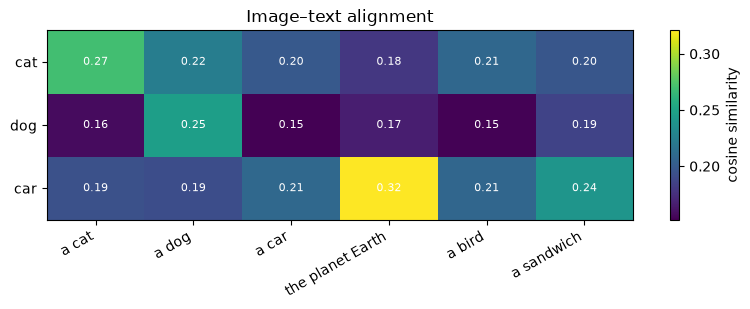

In [54]:
# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 3.2))
im = ax.imshow(sims.cpu().numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(images))); ax.set_yticklabels(list(images.keys()))
for i in range(sims.shape[0]):
    for j in range(sims.shape[1]):
        ax.text(j, i, f"{sims[i,j]:.2f}", ha="center", va="center",
                color="white", fontsize=8)
plt.colorbar(im, label="cosine similarity"); ax.set_title("Image–text alignment")
plt.tight_layout(); plt.show()


Notice the Earth photo (loaded under the name *"car"*) is **most** similar to
*"the planet Earth"*, not to *"a car"* — CLIP describes what it actually sees, regardless of the
filename we gave it. This is the whole point: the prediction comes from the image–text alignment,
not from any fixed label list.


### Why the *temperature* matters

CLIP doesn't feed raw cosine similarities (which live in a narrow band like 0.1–0.3) straight into
the softmax — it first multiplies by a large **learned temperature** (`logit_scale`, here ≈100).
That scaling turns lukewarm similarities into confident probabilities. Below, the same cosine row
for the cat image becomes far sharper once the temperature is applied.


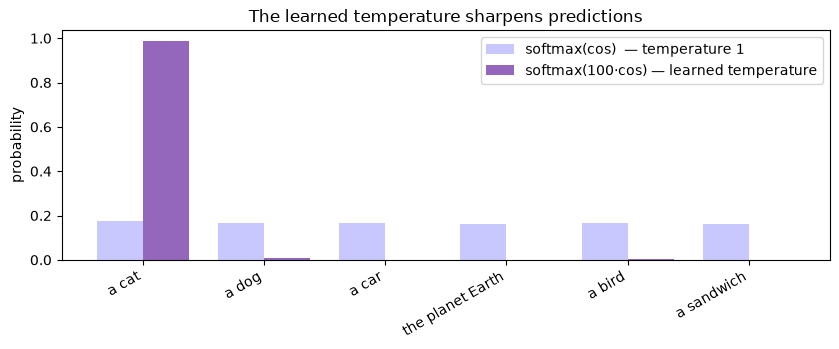

In [55]:
row = sims[0].detach().cpu()                    # cat image vs the 6 candidate labels
ls = model.logit_scale.exp().item()
p_raw  = row.softmax(0).numpy()
p_temp = (row * ls).softmax(0).numpy()

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.bar(x - w/2, p_raw,  w, label="softmax(cos)  — temperature 1", color="#c8c8ff")
ax.bar(x + w/2, p_temp, w, label=f"softmax({ls:.0f}·cos) — learned temperature", color="tab:purple")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("probability"); ax.set_title("The learned temperature sharpens predictions")
ax.legend(); plt.tight_layout(); plt.show()


### Seeing the contrastive objective concretely

Section 1 described training as *"make the diagonal of the image×caption matrix large."* Let's make
that literal: pair each of our three images with its **correct** caption and look at the 3×3
similarity matrix. The diagonal (matching pairs) should dominate — exactly what the contrastive
loss rewards.


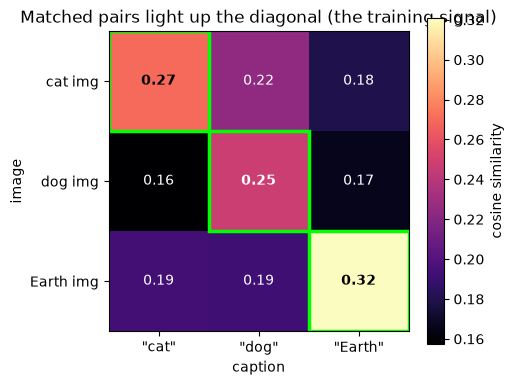

In [56]:
true_caps = ["a photo of a cat", "a photo of a dog", "a photo of the planet Earth"]
names = ["cat", "dog", "Earth"]
with torch.no_grad():
    cap_feat = F.normalize(model.encode_text(tokenizer(true_caps).to(device)), dim=-1)
    M = (image_features @ cap_feat.T).cpu().numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(M, cmap="magma")
ax.set_xticks(range(3)); ax.set_xticklabels([f'"{n}"' for n in names])
ax.set_yticks(range(3)); ax.set_yticklabels([f"{n} img" for n in names])
ax.set_xlabel("caption"); ax.set_ylabel("image")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                color="white" if M[i, j] < 0.8*M.max() else "black",
                weight="bold" if i == j else "normal")
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, ec="lime", lw=2.5))
plt.colorbar(im, label="cosine similarity")
ax.set_title("Matched pairs light up the diagonal (the training signal)")
plt.tight_layout(); plt.show()


## 5. Zero-shot classification, step by step

Zero-shot classification is now just three steps:

1. Write one text prompt per class and encode them → "classifier weights."
2. Encode the image.
3. Take `softmax(logit_scale · image · textᵀ)` and pick the argmax.

Let's wrap that into a small reusable function.


In [57]:
@torch.no_grad()
def zero_shot_classify(pil_image, class_names, template="a photo of a {}"):
    # 1. encode class prompts
    prompts = [template.format(c) for c in class_names]
    tfeat = F.normalize(model.encode_text(tokenizer(prompts).to(device)), dim=-1)
    # 2. encode image
    ifeat = F.normalize(model.encode_image(preprocess(pil_image).unsqueeze(0).to(device)), dim=-1)
    # 3. logits -> probabilities
    logit_scale = model.logit_scale.exp()
    probs = (logit_scale * ifeat @ tfeat.T).softmax(dim=-1).squeeze(0)
    return {c: p.item() for c, p in zip(class_names, probs)}

classes = ["dog", "cat", "tabby cat", "lynx"]
result = zero_shot_classify(images["cat"], classes)
for c, p in sorted(result.items(), key=lambda kv: -kv[1]):
    print(f"{c:>10s}: {p:6.2%}")


 tabby cat: 73.15%
       cat: 25.56%
      lynx:  1.03%
       dog:  0.26%


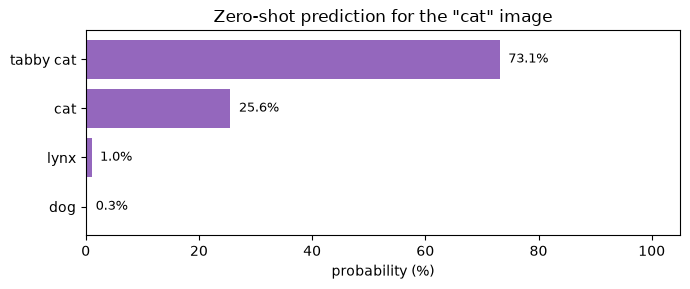

In [58]:
# The same prediction as a bar chart — far easier to read at a glance.
res = dict(sorted(result.items(), key=lambda kv: kv[1]))   # ascending for barh
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(list(res.keys()), [v*100 for v in res.values()], color="tab:purple")
ax.set_xlabel("probability (%)"); ax.set_xlim(0, 105)
ax.set_title('Zero-shot prediction for the "cat" image')
for v, b in zip(res.values(), bars):
    ax.text(v*100 + 1.5, b.get_y() + b.get_height()/2, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


Try changing `classes` above to anything you like — *"a tabby cat", "a Siamese cat", "a wild
lynx"* — and CLIP will rank them. You never retrained the model; you only changed the words.


## 6. Prompt engineering: phrasing matters

CLIP was trained on natural web captions, so a bare class word like `"cat"` is *out of
distribution* compared to a real caption. Wrapping the label in a template such as
`"a photo of a {}"` consistently improves accuracy. Averaging the embeddings of **several**
templates (prompt ensembling) helps even more — this is exactly the trick the original paper used
to push ImageNet zero-shot accuracy up by several points.

Let's see the effect on one image.


In [59]:
TEMPLATES = [
    "{}",
    "a photo of a {}",
    "a blurry photo of a {}",
    "a close-up photo of a {}",
    "a bright photo of a {}",
    "art of a {}",
]

@torch.no_grad()
def encode_class_ensemble(class_names, templates):
    # Average the normalized text embeddings over multiple templates per class.
    weights = []
    for c in class_names:
        prompts = [t.format(c) for t in templates]
        emb = F.normalize(model.encode_text(tokenizer(prompts).to(device)), dim=-1)
        emb = F.normalize(emb.mean(dim=0), dim=-1)   # average then renormalize
        weights.append(emb)
    return torch.stack(weights)

img = images["cat"]
ifeat = F.normalize(model.encode_image(preprocess(img).unsqueeze(0).to(device)), dim=-1)
ls = model.logit_scale.exp()

for label_template in ["{}", "a photo of a {}"]:
    w = encode_class_ensemble(classes, [label_template])
    p = (ls * ifeat @ w.T).softmax(-1).squeeze(0)
    top = classes[p.argmax()]
    print(f"single template {label_template!r:20s} -> {top:8s} ({p.max():.2%})")

w_ens = encode_class_ensemble(classes, TEMPLATES)
p = (ls * ifeat @ w_ens.T).softmax(-1).squeeze(0)
print(f"{len(TEMPLATES)}-template ensemble    -> {classes[p.argmax()]:8s} ({p.max():.2%})")


single template '{}'                 -> tabby cat (78.96%)
single template 'a photo of a {}'    -> tabby cat (73.15%)
6-template ensemble    -> tabby cat (78.40%)


## 7. Image ↔ text retrieval

Because images and text share a space, the same machinery does **retrieval** in either direction:

- *Text → image:* given a query caption, rank a gallery of images.
- *Image → text:* given an image, rank a list of captions.

Below we rank our three images against a free-text query.


In [60]:
@torch.no_grad()
def text_to_image_search(query, gallery_features, gallery_names):
    # Rank gallery images by similarity to a free-text query.
    q = F.normalize(model.encode_text(tokenizer([query]).to(device)), dim=-1)
    scores = (q @ gallery_features.T).squeeze(0)
    order = scores.argsort(descending=True)
    return [(gallery_names[i], scores[i].item()) for i in order]

for query in ["a fluffy pet animal", "something you can drive", "a view from space"]:
    ranked = text_to_image_search(query, image_features, list(images.keys()))
    pretty = ", ".join(f"{n} ({s:.2f})" for n, s in ranked)
    print(f"query: {query!r:28s} ->  {pretty}")


query: 'a fluffy pet animal'        ->  dog (0.25), cat (0.25), car (0.18)
query: 'something you can drive'    ->  car (0.20), cat (0.20), dog (0.19)
query: 'a view from space'          ->  car (0.29), cat (0.17), dog (0.14)


## 8. Visualizing the embedding space

A nice way to *see* the shared space is to project image and text vectors down to 2D with PCA and
plot them together. Matching concepts should cluster near each other even across the image/text
divide. (PCA on a handful of points is only a rough sketch, but it conveys the idea.)


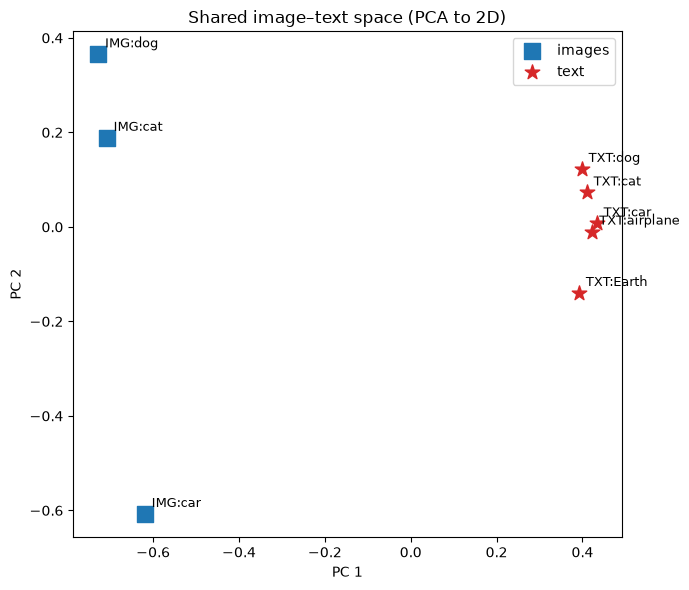

In [63]:
concepts = ["cat", "dog", "car", "airplane", "Earth"]
with torch.no_grad():
    text_emb = F.normalize(model.encode_text(
        tokenizer([f"a photo of a {c}" for c in concepts]).to(device)), dim=-1)

# Stack image vectors (3 we have) + text vectors, project with PCA
all_vecs = torch.cat([
    image_features.to(device),
    text_emb.to(device),
], dim=0).detach().cpu().numpy()
all_vecs = all_vecs - all_vecs.mean(0, keepdims=True)
U, S, Vt = np.linalg.svd(all_vecs, full_matrices=False)
coords = all_vecs @ Vt[:2].T

img_names = list(images.keys())
fig, ax = plt.subplots(figsize=(7, 6))
n_img = len(img_names)
ax.scatter(coords[:n_img, 0], coords[:n_img, 1], c="tab:blue", s=120, marker="s", label="images")
ax.scatter(coords[n_img:, 0], coords[n_img:, 1], c="tab:red", s=120, marker="*", label="text")
for i, name in enumerate(img_names):
    ax.annotate(f"IMG:{name}", coords[i], fontsize=9, xytext=(5, 5), textcoords="offset points")
for j, name in enumerate(concepts):
    ax.annotate(f"TXT:{name}", coords[n_img + j], fontsize=9, xytext=(5, 5), textcoords="offset points")
ax.legend(); ax.set_title("Shared image–text space (PCA to 2D)")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); plt.tight_layout(); plt.show()


## 9. Limitations and failure modes

CLIP is powerful but far from magic. Keep these in mind:

- **Prompt sensitivity.** Accuracy can swing several points based on wording; always use templates
  and consider ensembling.
- **Fine-grained / counting / spatial reasoning** are weak — CLIP is great at "what is this" and
  poor at "how many" or "which is left of which."
- **Bias.** Trained on uncurated web data, CLIP inherits social and cultural biases; audit before
  deploying on people.
- **Calibration.** The softmax probabilities are sharpened by the temperature and are *not*
  well-calibrated confidence estimates.
- **Adversarial fragility.** Tiny, imperceptible pixel perturbations can flip CLIP's prediction.
  This is the vulnerability the companion notebook investigates and tries to defend against.

The last point is the bridge to the next notebook.


## 10. Where this leads: multilingual CLIP & robustness

Two extensions matter for the companion tutorial:

1. **Multilingual CLIP.** Swap the English text tower for a *multilingual* one (e.g.
   `xlm-roberta-base-ViT-B-32`). Now the **same image encoder** is shared across many languages,
   and you can classify the same image with English, Korean, Spanish, French, or Japanese labels.

2. **Adversarial robustness.** An attacker who only perturbs the image to fool the *English*
   labels may leave the *other* languages still correct — the languages **disagree**. That
   disagreement is a signal you can detect, ensemble away, or train a small denoiser to purify.

That is precisely the idea explored in **"Multilingual Consensus Purification as a Defense Against
Adversarial Attacks on Zero-Shot Vision–Language Models."** Continue with the companion notebook,
`multilingual_adversarial_defence_tutorial.ipynb`, to build attacks and defenses end to end.

---

### Recap

- CLIP learns a **shared image–text embedding space** via a contrastive objective.
- Classification = encode class prompts as "weights," encode the image, take the nearest by
  cosine similarity — **no task-specific training**.
- **Prompt templates and ensembling** materially improve accuracy.
- The same space powers **retrieval** in both directions.
- Known weaknesses include prompt sensitivity, poor counting/spatial reasoning, bias, and
  **adversarial fragility** — motivating the defense tutorial.
